## Introdução
A rotina de processamento abaixo foi desenvolvido para estimar o estoque de biomassa viva acima do solo a partir de dados brutos de um inventário florestal realizado em uma área do bioma Caatinga. O inventário abrange 78 parcelas de 20x50 m nas quais foram mensurados indivíduos com DAP > 10 cm. Cada uma das parcelas possui duas sub parcelas de 10x10 m, nas quais foram mensurados indivíduos com DAP > 3 cm.
<br><br>
A estimativa foi feita por meio de equações alométricas específicas para a Caatinga, elaboradas por Sampaio & Silva (2005), e aplicadas no formato de equação de simples entrada e dupla entrada (ex.: DAP e Altura). A inclusão de uma segunda variável permite avaliar o ganho de precisão decorrente da inclusão da altura no modelo. Além disso, os resultados são apresentados em dois cenários de amostragem:
- **Sem estratificação**, a área do projeto é tratada como uma única unidade amostral homogênea.
- **Com estratificação**, segregando a área entre os estratos "Cristalino" e "Sedimentar" afim de capturar a heterogeneidade ambiental, conforme delimitação dos shapefiles disponibilizados.
<br>
<br>
Para cada combinação de cenário e equação, o estoque de biomassa é expresso em Mg.ha^-1 e em biomassa total da área (Mg), conforme o enunciado do desafio. Também são apresentadas as respectivas incertezas a 95% de confiança, calculada a partir do erro padrão da média.

In [1]:
import pandas as pd
import geopandas as gpd
import math as m
import matplotlib.pyplot as plt
from math import pi
from scipy import stats
from tkinter import  filedialog as filedialog

## Funções utilizadas

In [2]:
def leitor_de_arquivo(caminho, extensao):
    excel = ['xls', 'xlsx', 'xlsm', 'xlsb', 'odf', 'ods']

    if extensao in excel:
        # pd.ExcelFile(arquivo).sheet_names
        dados_temp = pd.read_excel(caminho, sheet_name = 1) # ajustado para metadados / dados
        return dados_temp
    elif extensao == 'csv':
        sep = [',', ';', '|', ' ']
        for s in sep:
            try:
                dados_temp = pd.read_csv(caminho,
                                sep = s,
                                encoding = 'latin-1')
                if len(dados_temp.columns) > 1:
                    return dados_temp
                else: 
                    print(f'ERRO com sep "{s}"')
            except Exception as e:
                print(e)
    else:
        print('Arquivo não suportado')

def padronizar_crs(shp1, shp2):
    if shp1.crs == shp2.crs:
        print('Ambos os arquivos possuem o mesmo sistema de coordenadas')
    else:
        shp1.to_crs(shp2.crs, inplace=True)
        print('O CRS do shapefile 1 foi alterado para o mesmo CRS do shapefile 2!')
        if shp1.crs == shp2.crs:
            print(shp1.crs.name)

def obter_extensao(caminho):
    return caminho.split('.')[-1]

def resultados_simples(biomassa_t_ha,std_da_media, intervalo_de_confianca, erro_amostral, erro_padrao, area_total):
    print('\n--- Sem Estratificação---')
    print(f'Estoque de biomassa: {biomassa_t_ha:.2f} Mg/ha')
    print(f'Área total: {area_total:.2f} ha')
    print(f'Estoque de biomassa em área total: {(biomassa_t_ha * area_total):,.2f} Mg')
    print(f'Desvio padrão da média: {std_da_media:.2f}')
    print(f'IC (95%): +/- {intervalo_de_confianca:.2f} Mg/ha')
    print(f'Erro padrão: {erro_padrao:.2f} Mg/ha')
    print(f'Erro amostral: {erro_amostral:.1f}%\n')

def resultados_estratificado(biomassa_t_ha,std_da_media, intervalo_de_confianca, erro_amostral, area_total):
    print('--- Com Estratificação ---')
    print(f'Estoque de biomassa: {biomassa_t_ha:.2f} Mg/ha')
    print(f'Área total: {area_total:.2f} ha')
    print(f'Estoque de biomassa em área total: {(biomassa_t_ha * area_total):,.2f} Mg')
    print(f'IC (95%): +/- {intervalo_de_confianca:.2f} Mg/ha')
    print(f'Erro padrão: {std_da_media:.2f} Mg/ha')
    print(f'Erro amostral: {erro_amostral:.1f}%\n')

# ------------- Equações alométricas -------------
# R² = 0.7005
def eq_biomassa_jamacaru (dap):
    return 0.0010 * pow(dap, 3.2327)

# R² = 0.9184
def eq_geral_simples_entrada (area_basal):
    return 0.2283 * pow(area_basal, 1.1475)
  
# R² = 0.9494
def eq_geral_dupla_entrada (area_basal, altura_m):
    return 0.1085 * pow((area_basal * altura_m), 0.9497)

def eq_small_spp (dap):
    return  0.2627 * pow(dap, 1.901)

def eq_large_spp (dap):
    return 0.2368 * pow(dap, 2.2219)

### Carregando dados

In [3]:
# pd.read_excel(r'C:/Users/Bruno/Desktop/Python/BrCarbon/avaliaçao_bruno/data/raw/dados_inventario.xlsx')

# Abre um modal para seleção do arquivo como caminho (string)
caminho_dataset = filedialog.askopenfilename(title="DATASET")
caminho_parcelas = filedialog.askopenfilename(title="PARCELAS")
caminho_estratos = filedialog.askopenfilename(title="ESTRATOS")

# Split separa a str de acordo com o separador definido e retorna uma lista 
extensao_arquivo = obter_extensao(caminho_dataset)

# Função otimizada que evita erros, principalmente com separadores e encoding de csv
dados = leitor_de_arquivo(caminho_dataset, extensao_arquivo)
dados.head()

,NUMERO_ARVORE,SUB_PARCELA,ID,FUSTE,DAP_cm,ALTURA_m,STATUS,NOME_POPULAR
0,rg01,DAP_3_Sub,P6_S15,a,8.1,6.0,viva,pacote
1,rg02,DAP_3_Sub,P6_S15,a,3.0,6.0,viva,mororo
2,rg03,DAP_3_Sub,P6_S15,a,6.8,6.0,viva,sabia
3,rg04,DAP_3_Sub,P6_S15,a,8.4,6.0,viva,pacote
4,rg05,DAP_3_Sub,P6_S15,a,6.0,6.5,viva,sabia


Uma vez que é necessária a análise por estrato, farei um spatial join no início do processamento para que o dataset contenha uma coluna indicativa do estrato.<br><br>Antes do join, preciso ter certeza que ambas geometrias estão no mesmos Sistema Coordenadas (CRS).<br><br>As principais informações que preciso extrair dos shapefiles são:
- Área total
- Área de cada estrato
- Quais parcelas pertencem a cada estrato

1. Lendo os arquivos e padronizando CRS

In [5]:
parcelas = gpd.read_file(caminho_parcelas)
estratos = gpd.read_file(caminho_estratos)

padronizar_crs(parcelas, estratos)

O CRS do shapefile 1 foi alterado para o mesmo CRS do shapefile 2!
WGS 84 / UTM zone 24S


Unindo os GeoDataFrames para extrair área total e por estrato. Utilizarei mais a frente para calcular as estimativas por estrato e área total. 

In [6]:
# O primeiro shp é o que mantêm as geometrias no join
parcelas_estratos = gpd.sjoin(parcelas, estratos, how='inner') # within > parcelas within estratos

parcelas_estratos = parcelas_estratos[['ID', 'grupo']]

Por padrão, a unidade de medida do atributo `.area` é a mesma do CRS. Nesse caso, o CRS WGS 84 está em metros, então o atributo `.area` retorna m² como unidade de medida.

In [7]:
# 0 = Cristalino
# 1 = Sedimentar

# Área do estrato / 10k para transformar em m²
cristalino_area_ha = estratos.area[0] / 10_000 
sedimentar_area_ha = estratos.area[1] / 10_000
area_total_ha = cristalino_area_ha + sedimentar_area_ha


# Área ponderada - usada na análise estratificada
peso_cristalino = cristalino_area_ha / area_total_ha
peso_sedimentar = sedimentar_area_ha / area_total_ha

Para saber quais parcelas estão em cada estrato, faço um `merge` das geometrias com o dataset utilizando como ID comum a coluna ID e, em seguida, renomeado-a para facilitar a associação com "parcela".

In [8]:
df = pd.merge(dados, parcelas_estratos, how='inner', on='ID')

df.rename(columns = {'ID': 'ID_parcela', 'grupo': 'GRUPO'}, 
                     inplace = True) # inplace evita criar outro df

## Explorando os dados

Aqui a ideia é ter uma noção geral dos dados, se tem algum dado faltando ou que foi preenchido de forma errada (dado categórico em coluna numérica e vice versa) e distribuição geral das variáveis. <br><br> No artigo, o autor descreve quais espécies foram selecionadas para a elaboração das equações alométricas e quais as consequências dessas escolhas. Saber a distribuição de diâmetro e altura, me ajuda a identificar se as condições do estudo se assemelham a realidade de campo e, consequentemente, se devo ou não considerar ajustes no dataset ou equações diferentes, elaboradas em áreas semelhantes a área do inventário.

In [9]:
df.isna().sum()

NUMERO_ARVORE    0
SUB_PARCELA      0
ID_parcela       0
FUSTE            0
DAP_cm           0
ALTURA_m         0
STATUS           0
NOME_POPULAR     0
GRUPO            0
dtype: int64

In [10]:
df.dtypes

NUMERO_ARVORE     object
SUB_PARCELA          str
ID_parcela           str
FUSTE                str
DAP_cm           float64
ALTURA_m         float64
STATUS               str
NOME_POPULAR         str
GRUPO                str
dtype: object

As métricas abaixo estão de acordo com o descrito no artigo.<br> Árvores de perfil baixo, raramente atingindo mais que 20 m de altura. 

In [11]:
print(f'Altura média: {df['ALTURA_m'].mean():.2f} m')
print(f'Altura mínima: {df['ALTURA_m'].min():.2f} m')
print(f'Altura máxima: {df['ALTURA_m'].max():.2f} m')
print('\n')
print(f'DAP médio: {df['DAP_cm'].mean():.2f} cm')
print(f'DAP mínimo: {df['DAP_cm'].min()} cm')
print(f'DAP máximo: {df['DAP_cm'].max()} cm')

Altura média: 5.59 m
Altura mínima: 1.00 m
Altura máxima: 14.20 m


DAP médio: 7.41 cm
DAP mínimo: 3.0 cm
DAP máximo: 42.0 cm


Extrapolar a equação para indivíduos com DAP > 30 cm não é recomendado, pois mesmo que sejam poucos indivíduos, podem introduzir grandes erros na estimativa. Ao todo, existem 13 indivíduos com DAP >= 30 cm, os quais serão removidos do dataset principal.

In [12]:
print(f'Indivíduos com DAP >= 30 cm removidos: {(df['DAP_cm'] >= 30).sum()}')

# Removendo os indivíduos com DAP >= 30 cm
df = df[df['DAP_cm'] <= 29]

Indivíduos com DAP >= 30 cm removidos: 13


Alguns gráficos exploratórios.

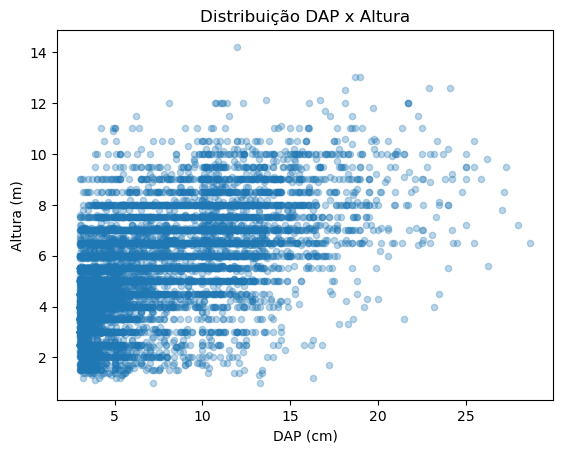

In [13]:
plt.scatter(df['DAP_cm'], df['ALTURA_m'],
            alpha = 0.3,
            s = 20) # s = size
plt.xlabel('DAP (cm)')
plt.ylabel('Altura (m)')
plt.title('Distribuição DAP x Altura')
plt.show()

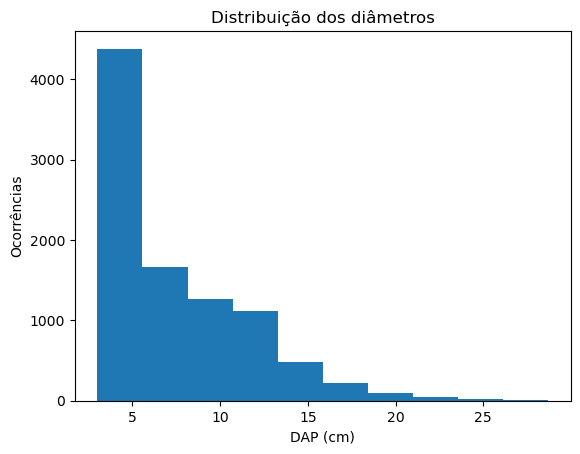

In [14]:
plt.hist(df['DAP_cm'])
plt.xlabel('DAP (cm)')
plt.ylabel('Ocorrências')
plt.title('Distribuição dos diâmetros')
plt.show()

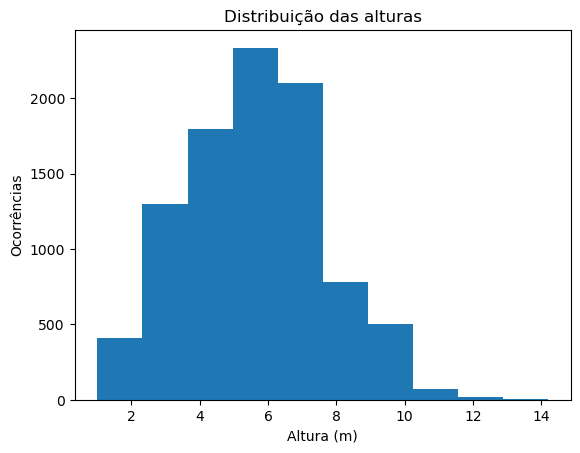

In [15]:
plt.hist(df['ALTURA_m'])
plt.xlabel('Altura (m)')
plt.ylabel('Ocorrências')
plt.title('Distribuição das alturas')
plt.show()

Como o artigo possui equações específicas para algumas espécies, pensei em aplicá-las individualemtne para as espécies encontradas no dataset, entretanto, uma vez que há apenas o nome comum (que pode sofrer variações regionais), optei por aplicar apenas a equação generalista.<br>Segundo o artigo, a eq. generalista é ideal para estimar biomassa no bioma, enquanto equações específicas são mais indicadas para estudos populacionais. A única equação específica utilizada, é para o indivíduo de nome popular Madacaru (C. jamacaru), um cactus arbustivo. O autor deixa claro que para estes indivíduos, deve-se aplicar a equação específica ao invés da eq. generalista.

In [ ]:
# individuos_unicos = df['NOME_POPULAR'].value_counts()
# print(individuos_unicos.to_string())

# Aplicar equações específicas para espécies que aparecem no artigo
# Espécie           Nome Comum      Ocorrências
# C. sonderianus = Marmeleiro (~preto / branco), 1372 
# C. jamacaru = Mandacaru, 26 
# A. pyrifolium = Pereiro, 77 
# C. pyramidalis = Catingueira, 915 
# M. hostilis = Jurema preta, 180 
# M. urundeuva = Aroeira, 19 

## Processando os dados

As variáveis apresentadas nas equações desevolvidas por Sampaio & Silva (2005) e utilizadas neste script estão nas seguintes unidades:
- Área basal a altura do peito (ABH): cm²
- Diâmetro a altura do peito (DBH): cm
- Altura (H): m

Como uma das equações que selecionei utiliza área basal como dado de entrada, vou criar uma coluna apenas com essa variável, expressa em cm².
<br>
O desafio pede estoque de biomassa em Mg ha e em área total. Nesse ponto fiquei em dúvida se devo ou não incluir o estoque na biomassa morta. No contexto de projetos de carbono, um dos _pools_ refere-se justamente a _deadwood_, faria sentido separa o dataset e fazer a estimativa apenas para esse _pool_, mas a princípio, irei excluir as árvores mortas e calcular as estimativas separadas apenas para indivíduos vivos.

In [16]:
df['AREA_BASAL_cm2'] = (pi/4) * pow(df['DAP_cm'], 2)

# Pool deadwood faz sentido ser incluído?
df = df[df['STATUS'].str.lower() == 'viva']

## Cenário sem estratificação
### Equação Simples Entrada

In [17]:
df_simples = df.copy()
df_dupla = df.copy()

Como as parcelas possuem sub parcelas, é preciso calcular um fator de expansão para cada área. 
- Parcela principal >> 20x50 m = 1000 m²
- Sub parcelas (2 por parcela) >> 10x10 m * 2 = 200 m² 

Crio um subset para cada conjunto, isso facilita a posterior aplicação dos fatores de expansão corretos. 

In [18]:
area_parcela_m2 = 1000
area_parcela_ha = area_parcela_m2 / 10_000
print(f'\nÁrea parcela DAP > 10 cm: {area_parcela_m2} m²')

area_sub_m2 = 200
area_sub_ha = area_sub_m2 / 10_000
print(f'Área sub parcela DAP > 3 cm: {area_sub_m2} m²')

fator_exp_parcela = 10_000 / area_parcela_m2
print(f'\nFator de expansão para a parcela: {fator_exp_parcela} ha^(-1)')

fator_exp_sub = 10_000 / area_sub_m2
print(f'Fator de expansão para a sub parcela: {fator_exp_sub} ha^(-1)')


Área parcela DAP > 10 cm: 1000 m²
Área sub parcela DAP > 3 cm: 200 m²

Fator de expansão para a parcela: 10.0 ha^(-1)
Fator de expansão para a sub parcela: 50.0 ha^(-1)


Aplicação da equação de simples entrada e validação da criação da coluna biomassa_kg

In [19]:
df_simples['BIOMASSA_kg'] = df_simples.apply(lambda x: eq_biomassa_jamacaru(x['DAP_cm'])
                                    if x['NOME_POPULAR'] == 'Mandacaru'
                                    else eq_geral_simples_entrada(x['AREA_BASAL_cm2']),
                                    axis=1)

df_simples

,NUMERO_ARVORE,SUB_PARCELA,ID_parcela,FUSTE,DAP_cm,ALTURA_m,STATUS,NOME_POPULAR,GRUPO,AREA_BASAL_cm2,BIOMASSA_kg
0,rg01,DAP_3_Sub,P6_S15,a,8.1,6.0,viva,pacote,Cristalino,51.529974,21.042371
1,rg02,DAP_3_Sub,P6_S15,a,3.0,6.0,viva,mororo,Cristalino,7.068583,2.153351
2,rg03,DAP_3_Sub,P6_S15,a,6.8,6.0,viva,sabia,Cristalino,36.316811,14.084113
3,rg04,DAP_3_Sub,P6_S15,a,8.4,6.0,viva,pacote,Cristalino,55.417694,22.874021
4,rg05,DAP_3_Sub,P6_S15,a,6.0,6.5,viva,sabia,Cristalino,28.274334,10.567656
...,...,...,...,...,...,...,...,...,...,...,...
9318,rg17,DAP_3_Sub,P1_S1,a,3.2,3.8,viva,mororo,Sedimentar,8.042477,2.497128
9319,rg18,DAP_3_Sub,P1_S1,a,4.3,3.8,viva,mororo,Sedimentar,14.522012,4.919621
9320,rg19,DAP_3_Sub,P1_S1,a,3.8,2.5,viva,angico branco,Sedimentar,11.341149,3.704460
9321,rg20,DAP_3_Sub,P1_S1,a,3.1,3.0,viva,sp18,Sedimentar,7.547676,2.321649


A equação retorna o dado em kg, portanto, converto e crio uma coluna em toneladas.

In [20]:
df_simples['BIOMASSA_t'] = df_simples['BIOMASSA_kg'] / 1000

De posse dos fatores de expansão, os dados são agrupados pelo ID de cada parcela e realizado o produto da biomassa (t) calculada pelo fator de expansão. O resultado de cada registro da parcela _i_ é somado obtendo o total por hectare por parcela.

In [21]:
df_simples_parc = df_simples[df_simples['SUB_PARCELA'] == 'DAP_10_Plot']
df_simples_sub = df_simples[df_simples['SUB_PARCELA'] == 'DAP_3_Sub']


biomassa_parcela = df_simples_parc.groupby(['ID_parcela', 'GRUPO'])['BIOMASSA_t'].sum() * fator_exp_parcela # resultado em t/ha ou Mg/ha
biomassa_sub = df_simples_sub.groupby(['ID_parcela', 'GRUPO'])['BIOMASSA_t'].sum() * fator_exp_sub 

# total
biomassa_por_parcela = (biomassa_parcela + biomassa_sub).to_frame('BIOMASSA_por_parcela_t_ha')

Unindo novamente o subset ao dataset principal e sumarisando os dados 

In [22]:
df_simples = df_simples.merge(biomassa_por_parcela, how='left', on='ID_parcela')

#### Calculando estatísticas sem estratificação

In [24]:
media_biomassa_t_ha = biomassa_por_parcela['BIOMASSA_por_parcela_t_ha'].mean()
std_biomassa_t_ha = biomassa_por_parcela['BIOMASSA_por_parcela_t_ha'].std()
n = biomassa_por_parcela['BIOMASSA_por_parcela_t_ha'].count()
erro_padrao = std_biomassa_t_ha/m.sqrt(n)
t = stats.t.ppf(q=0.975, df= n-1) # t de student para 95#
ic = t * erro_padrao # Intervalo de confiança
erro_amostral = (ic / media_biomassa_t_ha) * 100

print('>> Sem estratificação')
resultados_simples(media_biomassa_t_ha, std_biomassa_t_ha, ic, erro_amostral, erro_padrao, area_total_ha)

>> Sem estratificação

--- Sem Estratificação---
Estoque de biomassa: 46.82 Mg/ha
Área total: 6193.34 ha
Estoque de biomassa em área total: 289,946.21 Mg
Desvio padrão da média: 14.58
IC (95%): +/- 3.29 Mg/ha
Erro padrão: 1.65 Mg/ha
Erro amostral: 7.0%



#### Calculando estatísticas com estratificação

Aqui eu crio um dicionário com os dados estatísticos por estrato. O loop itera pelo subset `biomassa_por_parcela_est` e extrai a média, variância e número de parcelas por estrato.

In [25]:
biomassa_por_parcela_est = biomassa_por_parcela.reset_index(level='GRUPO')
estats = dict()

for nome_estrato, grupo in biomassa_por_parcela_est.groupby('GRUPO'):
    # print(nome_estrato)
    media = grupo['BIOMASSA_por_parcela_t_ha'].mean()
    var = grupo['BIOMASSA_por_parcela_t_ha'].var()
    n = len(grupo) # número de parcelas

    estats[nome_estrato] = {'media': media,
                         'var': var,
                         'n': n}

# Peso ponderado calculado no início da análise
estats['Cristalino']['peso'] = peso_cristalino
estats['Sedimentar']['peso'] = peso_sedimentar

estats                         

{'Cristalino': {'media': np.float64(46.607714804346166),
  'var': np.float64(76.1579609557838),
  'n': 30,
  'peso': np.float64(0.4216784173250731)},
 'Sedimentar': {'media': np.float64(46.94584379119791),
  'var': np.float64(301.14614897094174),
  'n': 48,
  'peso': np.float64(0.578321582674927)}}

In [50]:
a = biomassa_por_parcela_est[biomassa_por_parcela_est['GRUPO'] == 'Cristalino']['BIOMASSA_por_parcela_t_ha']
b = biomassa_por_parcela_est[biomassa_por_parcela_est['GRUPO'] == 'Sedimentar']['BIOMASSA_por_parcela_t_ha']

{'whiskers': [<matplotlib.lines.Line2D at 0x2120ec9dfd0>,
 'caps': [<matplotlib.lines.Line2D at 0x2120ec9d6a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2120ec9e510>,
 'medians': [<matplotlib.lines.Line2D at 0x2120ec9d550>,
 'fliers': [<matplotlib.lines.Line2D at 0x2120ec9cec0>,
 'means': []}

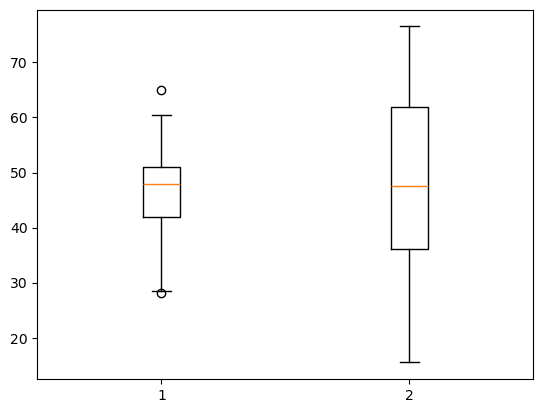

In [51]:
plt.boxplot([a,b])

Verificando se há outliers no estrato sedimentar, pois a variância do estrato sedimentar está muito alta, indicando maior heterogeneidade quando comparado ao estrato Cristalino.
Nessa rotina não foi feita a ANOVA, entretanto, pelos resultados acima deduzo que a análise acusaria diferença significativa entre estratos.<br><br>Ao observar os resultados abaixo, a mediana é muito próxima a média, indicando uma distribuição quase simétrica. Caso a diferença entre média e mediana fosse alta, isso indicaria a presença de outliers que distorcem o valor médio.

In [35]:
biomassa_por_parcela_est[biomassa_por_parcela_est['GRUPO'] == 'Sedimentar']['BIOMASSA_por_parcela_t_ha'].describe()

count    48.000000
mean     46.945844
std      17.353563
min      15.498839
25%      36.058016
50%      47.550284
75%      61.939045
max      76.524594
Name: BIOMASSA_por_parcela_t_ha, dtype: float64

Cálculo das estatísticas agregadas

In [52]:
# resultados['Cristalino']['media']
media_estratos = 0
var_estratos = 0
n_total = 0
for estrato, grupo in estats.items():
    media_estratos += grupo['media'] * grupo['peso']
    var_estratos += (grupo['var'] / grupo['n']) * (pow(grupo['peso'], 2))
    n_total += grupo['n']

In [55]:
media_biomassa_t_ha = media_estratos
erro_padrao = m.sqrt(var_estratos)
t = stats.t.ppf(0.975, df=n_total - len(estats))
ic = t * erro_padrao
erro_amostral = (ic / media_estratos) * 100

resultados_estratificado(media_biomassa_t_ha, erro_padrao, ic, erro_amostral, area_total_ha)

--- Com Estratificação ---
Estoque de biomassa: 46.80 Mg/ha
Área total: 6193.34 ha
Estoque de biomassa em área total: 289,868.59 Mg
IC (95%): +/- 3.18 Mg/ha
Erro padrão: 1.60 Mg/ha
Erro amostral: 6.8%



## Equação Dupla Entrada

Aqui a lógica é a mesma, a única diferença está no bloco de código abaixo, onde alteramos a equação e fornecemos área basal e altura como parâmetros de entrada ao invés de DAP.

In [58]:
df_dupla['BIOMASSA_t'] = df_dupla.apply(lambda lin: eq_biomassa_jamacaru(lin['DAP_cm']) / 1000
                                  if lin['NOME_POPULAR'] == 'Mandacaru'
                                  else eq_geral_dupla_entrada(lin['AREA_BASAL_cm2'], lin['ALTURA_m']) / 1000,
                                  axis=1)

In [59]:
df_dupla_parc = df_dupla[df_dupla['SUB_PARCELA'] == 'DAP_10_Plot']
df_dupla_sub = df_dupla[df_dupla['SUB_PARCELA'] == 'DAP_3_Sub']

biomassa_parcela = df_dupla_parc.groupby(['ID_parcela', 'GRUPO'])['BIOMASSA_t'].sum() * fator_exp_parcela # resultado em t/ha ou Mg/ha
biomassa_sub = df_dupla_sub.groupby(['ID_parcela', 'GRUPO'])['BIOMASSA_t'].sum() * fator_exp_sub
biomassa_por_parcela = (biomassa_parcela + biomassa_sub).to_frame('BIOMASSA_por_parcela_t_ha')

In [60]:
df_dupla = df_dupla.merge(biomassa_por_parcela, how='left', on='ID_parcela')

### Calculando estatísticas sem estratificação

In [61]:
media_biomassa_t_ha = biomassa_por_parcela['BIOMASSA_por_parcela_t_ha'].mean()
std_biomassa_t_ha = biomassa_por_parcela['BIOMASSA_por_parcela_t_ha'].std()
n = biomassa_por_parcela['BIOMASSA_por_parcela_t_ha'].count()
erro_padrao = std_biomassa_t_ha/m.sqrt(n)
t = stats.t.ppf(q=0.975, df= n-1) # t de student para 95#
ic = t * erro_padrao # Intervalo de confiança
erro_amostral = (ic / media_biomassa_t_ha) * 100

print('>>> Dupla Entrada ')
resultados_simples(media_biomassa_t_ha, std_biomassa_t_ha, ic, erro_amostral, erro_padrao, area_total_ha)

>>> Dupla Entrada 

--- Sem Estratificação---
Estoque de biomassa: 55.87 Mg/ha
Área total: 6193.34 ha
Estoque de biomassa em área total: 346,006.64 Mg
Desvio padrão da média: 22.34
IC (95%): +/- 5.04 Mg/ha
Erro padrão: 2.53 Mg/ha
Erro amostral: 9.0%



### Calculando estatísticas com estratificação

In [62]:
biomassa_por_parcela_est = biomassa_por_parcela.reset_index(level='GRUPO')

In [63]:
estats = dict()

for nome_estrato, grupo in biomassa_por_parcela_est.groupby('GRUPO'):
    # print(nome_estrato)
    media = grupo['BIOMASSA_por_parcela_t_ha'].mean()
    var = grupo['BIOMASSA_por_parcela_t_ha'].var()
    n = len(grupo) # número de parcelas

    estats[nome_estrato] = {'media': media,
                         'var': var,
                         'n': n}

# Peso ponderado calculado no início da análise
estats['Cristalino']['peso'] = peso_cristalino
estats['Sedimentar']['peso'] = peso_sedimentar

estats    

{'Cristalino': {'media': np.float64(53.56879689438291),
  'var': np.float64(148.61997902185743),
  'n': 30,
  'peso': np.float64(0.4216784173250731)},
 'Sedimentar': {'media': np.float64(57.30422220048371),
  'var': np.float64(720.27342707565),
  'n': 48,
  'peso': np.float64(0.578321582674927)}}

In [64]:
# checkando se há outliers no estrato sedimentar, var muito alta
biomassa_por_parcela_est[biomassa_por_parcela_est['GRUPO'] == 'Sedimentar']['BIOMASSA_por_parcela_t_ha'].describe()

count     48.000000
mean      57.304222
std       26.837910
min       13.326615
25%       38.948621
50%       55.276657
75%       83.634083
max      112.436848
Name: BIOMASSA_por_parcela_t_ha, dtype: float64

In [65]:
# resultados['Cristalino']['media']
media_estratos = 0
var_estratos = 0
n_total = 0
for estrato, grupo in estats.items():
    media_estratos += grupo['media'] * grupo['peso']
    var_estratos += (grupo['var'] / grupo['n']) * (pow(grupo['peso'], 2))
    n_total += grupo['n']

In [66]:
media_biomassa_t_ha = media_estratos
erro_padrao = m.sqrt(var_estratos)
t = stats.t.ppf(0.975, df=n_total - len(estats))
ic = t * erro_padrao
erro_amostral = (ic / media_estratos) * 100

resultados_estratificado(media_biomassa_t_ha, erro_padrao, ic, erro_amostral, area_total_ha)

--- Com Estratificação ---
Estoque de biomassa: 55.73 Mg/ha
Área total: 6193.34 ha
Estoque de biomassa em área total: 345,149.20 Mg
IC (95%): +/- 4.84 Mg/ha
Erro padrão: 2.43 Mg/ha
Erro amostral: 8.7%

